## Generación:

Se generará un set de espectros sintéticos en el rango de Sub-Neptunos.

Me tomé de base el trabajo que hicieron en ARIEL ABC @changeatESAArielDataChallenge2023

- Recordemos que estos tienen atmósferas primarias: fill gas **H₂–He** y con He/H2 = 0.17  => CIA H2-H2 y H2-He
- Las presiones se dajarán fijas en P_base = 10 bar y P_top = 1e-7 bar.
- La temperatura se toma en un rango entre 250-700 K con rango de 50. @parcSuperEarthsSubNeptunesObservational2024
- Inicialmente no habrán nubes, pero luego se pueden poner en el ruido. (en ABC no lo hacen para todos)
- Las moléculas químicas serán las del ABC:
	- H2O : -7,-1; NaN
	- CO2: -9, -1; NaN
	- CH4: -8, -1; NaN
	- NH3: -7, -1; NaN
	- El CO es dificil de detectar y se suele chocar con el CO2.

  
  


## Librería


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import multirex as mrex
import taurex as trex
import pandas as pd
from typing import Any
import sys
import seaborn as sns

Numba not installed, using numpy instead
Loading MultiREx version 0.3.1


In [2]:
mrex.Util.get_gases()
mrex.Util.get_stellar_phoenix()
mrex.Util.list_gases()

The opacity database already exists at: c:\Proyectos\Astro\AEspectra\exp 3\opacidades-todas
The directory to Phoenix already exists in the specified path:  current directory
Available gases in the database:
['C2H6', 'N2', 'CO2', 'H2O', 'SO2', 'DMS', 'O2', 'CO', 'NO2', 'CH4', 'HCN', 'CH3Cl', 'NH3', 'O3']


## Espectros

Se generarán con trappist 1e, pero podemos también usar la Tierra orbitando una M9.

Parámetros básicos del sistema, a revisar el rango del NIrspec Prism, tal vez mejor tomar todos los puntos del espectro

In [3]:

import copy
star= mrex.Star(temperature=3500,radius=0.468, mass=0.495,phoenix_path="")
planet= mrex.Planet(radius=2.461,mass=7.2)


atmH2 = mrex.Atmosphere(temperature=250,base_pressure=10e5,
                           top_pressure=1e-3, fill_gas=["H2", "He"],
                           cia = ["H2-H2", "H2-He"])

planet.set_atmosphere(atmH2)

sistema_H2 = mrex.System(planet=planet,star=star,
                    sma=0.1429)

mrex.Util.get_CIAs(
    ['H2-H2', "H2-He"],
    path="CIA"
)
sistema_H2.make_tm()



#load txt waves.txt, this file contains the wavenumber grid simulated by PandExo
waves=np.loadtxt("waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

The directory to Phoenix already exists in the specified path:  current directory


#### CO2, CH4, H2O

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


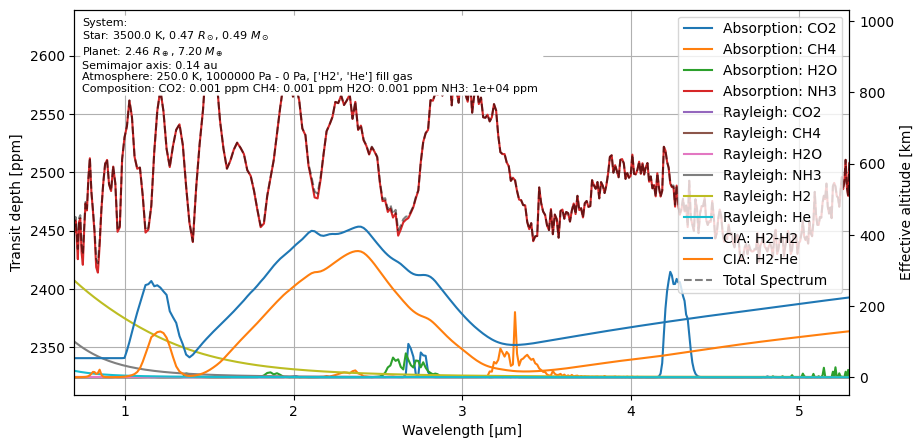

(<Figure size 1000x500 with 2 Axes>,
 <Axes: xlabel='Wavelength [μm]', ylabel='Transit depth [ppm]'>)

In [4]:
import copy

sistema_H2.planet.atmosphere.add_gas("CO2", -9)
sistema_H2.planet.atmosphere.add_gas("CH4", -9)
sistema_H2.planet.atmosphere.add_gas("H2O", -9)
sistema_H2.planet.atmosphere.add_gas("NH3", -2)

sistema_H2.make_tm()
sistema_H2.plot_contributions(wn_grid)


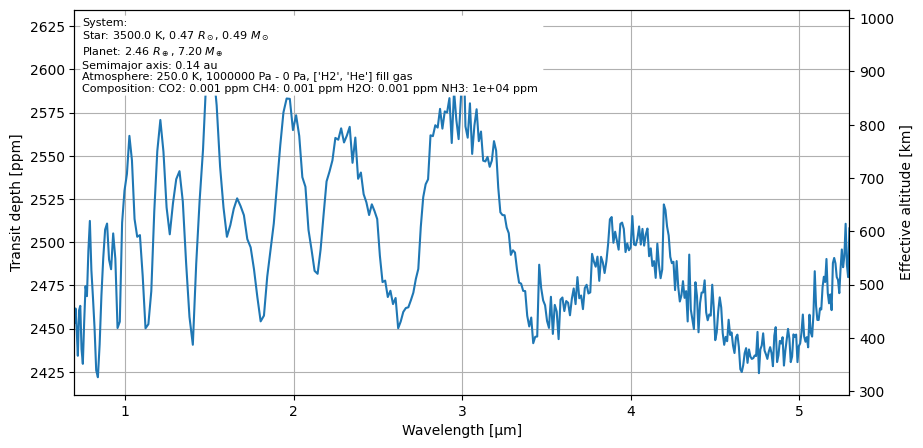

(<Figure size 1000x500 with 2 Axes>,
 <Axes: xlabel='Wavelength [μm]', ylabel='Transit depth [ppm]'>)

In [5]:
sistema_H2.plot_spectrum(wn_grid)

In [6]:
parameter_space = {
    #"planet.atmosphere.composition.NH3": [-10,-7,-6,-5,-4,-3,-2],
    "planet.atmosphere.composition.NH3": {"min": -7,"max": -2, "n":6, 'include_absence': True},
    "planet.atmosphere.temperature": [250, 300, 350, 400, 450],
    "planet.atmosphere.composition.CH4": {"min": -8,"max": -1, "n":8, 'include_absence': True},
    "planet.atmosphere.composition.CO2": {"min": -10,"max": -1, "n":10},
    "planet.atmosphere.composition.H2O": {"min": -7,"max": -2, "n":6, 'include_absence': True},
}




H2_data = sistema_H2\
    .explore_parameter_space(
    wn_grid= wn_grid, parameter_space= parameter_space,
    header = True, observations= False, n_jobs = -1, 
)
    

  0%|          | 48/22050 [01:19<11:03:25,  1.81s/it]c:\Users\User\anaconda3\envs\multirex_dev\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 22050/22050 [8:46:50<00:00,  1.43s/it]  


In [7]:
H2_data[["atm CO2", "atm H2O", "atm NH3", "atm CH4"]]

,atm CO2,atm H2O,atm NH3,atm CH4
0,-10.0,-7.0,-7.0,-8.0
1,-10.0,-6.0,-7.0,-8.0
2,-10.0,-5.0,-7.0,-8.0
3,-10.0,-4.0,-7.0,-8.0
4,-10.0,-3.0,-7.0,-8.0
...,...,...,...,...
22045,-1.0,-5.0,NaN,NaN
22046,-1.0,-4.0,NaN,NaN
22047,-1.0,-3.0,NaN,NaN
22048,-1.0,-2.0,NaN,NaN


In [8]:
## save df in joblib file

import joblib

joblib.dump(H2_data, "specs/K2-18b_data.joblib")

H2_data

,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,atm fill_gas,atm cia,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002405,0.002406,0.002407,0.002408,0.002409,0.002410,0.002411,0.002412,0.002413,0.002414
1,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002405,0.002406,0.002407,0.002408,0.002409,0.002411,0.002412,0.002412,0.002413,0.002414
2,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002405,0.002406,0.002407,0.002408,0.002410,0.002412,0.002413,0.002412,0.002413,0.002414
3,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002405,0.002406,0.002407,0.002409,0.002413,0.002417,0.002417,0.002413,0.002415,0.002416
4,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002405,0.002406,0.002407,0.002412,0.002422,0.002430,0.002428,0.002418,0.002420,0.002420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22045,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002376,0.002377,0.002377,0.002378,0.002379,0.002380,0.002381,0.002381,0.002381,0.002382
22046,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002376,0.002377,0.002378,0.002379,0.002381,0.002382,0.002383,0.002381,0.002382,0.002382
22047,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002376,0.002377,0.002379,0.002382,0.002387,0.002389,0.002391,0.002384,0.002385,0.002384
22048,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002375,0.002378,0.002382,0.002390,0.002399,0.002403,0.002405,0.002393,0.002393,0.002390


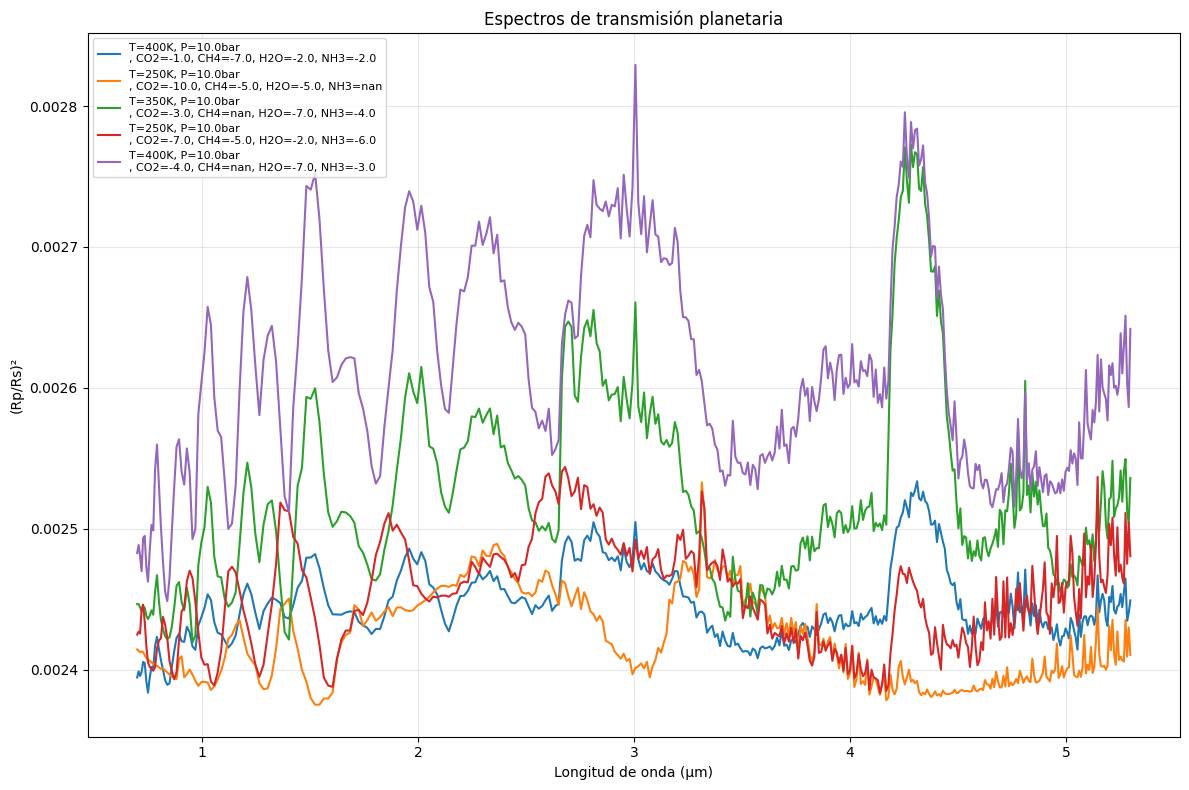

In [13]:
spectra = H2_data.data
Headers = H2_data.params




# Seleccionamos 5 espectros aleatorios y los graficamos con sus parámetros físicos
import random
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos 5 índices aleatorios
indices_aleatorios = random.sample(range(len(spectra)), 5)

# Creamos la figura
plt.figure(figsize=(12, 8))

# Para cada índice aleatorio, graficamos el espectro correspondiente
for idx in indices_aleatorios:
    # Obtenemos los datos del espectro y sus parámetros
    espectro_datos = spectra.iloc[idx]
    espectro_params = Headers.iloc[idx]
    
    # Extraemos los parámetros físicos para la leyenda
    temperatura = espectro_params['atm temperature']
    presion_base = espectro_params['atm base_pressure']
    co2 = espectro_params['atm CO2']
    ch4 = espectro_params['atm CH4']
    h2o = espectro_params['atm H2O']
    nh3 = espectro_params['atm NH3']
    
    # Extraemos las longitudes de onda (nombres de columnas) y los valores de (rp/rs)^2
    longitudes_onda = [float(col) for col in spectra.columns]
    valores_espectro = espectro_datos.values
    
    # Graficamos el espectro
    plt.plot(longitudes_onda, valores_espectro, 
             label=f'T={temperatura}K, P={presion_base/1e5:.1f}bar\n, CO2={co2}, CH4={ch4}, H2O={h2o}, NH3={nh3}')

# Configuramos el gráfico
plt.xlabel('Longitud de onda (μm)')
plt.ylabel('(Rp/Rs)²')
plt.title('Espectros de transmisión planetaria')
plt.legend(loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostramos el gráfico
plt.show()